## 03 - Baseline: Regressão Logística

**Tech Challenge — Fase 1 | Machine Learning Engineering — FIAP**

**Projeto:** Customer Churn Prediction

**Grupo:** 56

---

### Objetivo

Este notebook tem como objetivo construir um modelo baseline utilizando Regressão Logística para prever o churn de clientes, servindo como referência para comparação com modelos mais robustos que serão desenvolvidos nas próximas etapas do projeto.

Após a realização da Análise Exploratória dos Dados (EDA) e da definição do protocolo metodológico de avaliação, inicia-se nesta etapa o desenvolvimento do primeiro modelo supervisionado do projeto.

A Regressão Logística foi escolhida como **baseline estatístico**, pois é um algoritmo amplamente utilizado em problemas de classificação binária, possui elevada interpretabilidade e serve como referência para comparação com modelos mais complexos.

Neste notebook serão realizadas todas as etapas necessárias para construção do modelo, incluindo:

- preparação dos dados;
- criação do pipeline de pré-processamento;
- treinamento da Regressão Logística;
- geração das predições;
- avaliação das métricas técnicas;
- análise da matriz de confusão;
- interpretação dos resultados sob a perspectiva do negócio.

Ao final deste notebook será obtido o primeiro modelo supervisionado do projeto, que servirá como baseline para comparação com os demais algoritmos desenvolvidos nas próximas etapas.

---

In [ ]:
# ============================================================
# ETAPA 1 - IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================
# Importação das bibliotecas utilizadas durante o
# desenvolvimento do modelo de Regressão Logística.
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

plt.style.use("default")

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [ ]:
# ============================================================
# ETAPA 2 - CARREGAMENTO DOS DADOS
# ============================================================
# Carregamento do conjunto de dados e inspeção inicial da
# estrutura da base utilizada neste projeto.
# ============================================================

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset não encontrado em:\n{DATA_PATH.resolve()}"
    )

df = pd.read_csv(DATA_PATH)

print("Base carregada com sucesso.\n")

print(f"Quantidade de registros : {df.shape[0]:,}".replace(",", "."))
print(f"Quantidade de variáveis : {df.shape[1]}")

print("\nInformações da base:")
df.info()

print("\nPrimeiras observações:")
display(df.head())

Base carregada com sucesso.

Quantidade de registros : 7.043
Quantidade de variáveis : 21

Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 n

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Conclusão do Carregamento dos Dados

O conjunto de dados foi carregado com sucesso, permitindo confirmar a quantidade de registros, o número de variáveis e os respectivos tipos de dados.

A inspeção inicial também possibilitou visualizar os primeiros registros da base, garantindo que a importação foi realizada corretamente antes do início das etapas de preparação dos dados.

Na próxima etapa será realizada a preparação das variáveis, incluindo o tratamento da variável alvo e a definição das variáveis explicativas utilizadas no treinamento do modelo.

---

In [ ]:
# ============================================================
# ETAPA 3 - PREPARAÇÃO DAS VARIÁVEIS
# ============================================================
# Preparação das variáveis utilizadas no treinamento do modelo.
# ============================================================

df = df.copy()

# Conversão da variável TotalCharges para formato numérico
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Conversão da variável alvo
df["Churn"] = (
    df["Churn"]
    .map({
        "No": 0,
        "Yes": 1
    })
    .astype(int)
)

# Separação das variáveis
X = df.drop(
    columns=[
        "customerID",
        "Churn"
    ]
)

y = df["Churn"]

print(f"{'Variáveis explicativas:':30} {X.shape[1]:,}".replace(",", "."))
print(f"{'Observações:':30} {X.shape[0]:,}".replace(",", "."))
print(f"{'Classe positiva (Churn):':30} {y.sum():,}".replace(",", "."))

Variáveis explicativas:        19
Observações:                   7.043
Classe positiva (Churn):       1.869


#### Conclusão da Preparação das Variáveis

Nesta etapa foi definida a estrutura que será utilizada durante o treinamento do modelo de Regressão Logística.

A variável **Churn** foi convertida para formato binário, permitindo sua utilização em algoritmos de classificação supervisionada. A variável **customerID** foi removida por representar apenas um identificador único, sem contribuição preditiva para o modelo.

Ao final da etapa, foram definidas as variáveis explicativas (**X**) e a variável resposta (**y**), que serão utilizadas no processo de pré-processamento e treinamento do modelo.

---

### ETAPA 4 - Pré-processamento dos Dados

Antes do treinamento da Regressão Logística, é necessário preparar adequadamente as variáveis do conjunto de dados.

Como a base possui variáveis numéricas e categóricas, será utilizada uma estratégia de pré-processamento diferente para cada tipo de variável.

O objetivo desta etapa é construir um pipeline totalmente reproduzível, evitando vazamento de dados (Data Leakage) e garantindo que exatamente o mesmo tratamento seja aplicado durante treinamento e inferência.

Serão realizadas as seguintes etapas:

- identificação das variáveis numéricas e categóricas;
- criação do pipeline para variáveis numéricas;
- criação do pipeline para variáveis categóricas;
- construção do ColumnTransformer;
- divisão entre treino e teste.

In [ ]:
# ============================================================
# ETAPA 4.1 - IDENTIFICAÇÃO DAS VARIÁVEIS
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Variáveis numéricas : {len(numeric_features)}")
print(f"Variáveis categóricas : {len(categorical_features)}")

print("\nVariáveis numéricas:")
print(numeric_features)

print("\nVariáveis categóricas:")
print(categorical_features)

Variáveis numéricas : 4
Variáveis categóricas : 15

Variáveis numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Variáveis categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


#### Conclusão da Identificação das Variáveis

As variáveis foram separadas automaticamente de acordo com seus respectivos tipos de dados.

Essa abordagem torna o código mais robusto e facilita futuras modificações na base de dados, eliminando a necessidade de informar manualmente quais variáveis pertencem a cada grupo.

A partir dessa separação será possível construir pipelines específicos para cada tipo de variável.

In [ ]:
# ============================================================
# ETAPA 4.2 - PIPELINE NUMÉRICO
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

print("Pipeline Numérico:")

display(numeric_transformer)

Pipeline Numérico:


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

#### Conclusão do Pipeline Numérico

Foi definido um pipeline para o tratamento das variáveis numéricas.

Esse pipeline garante que valores ausentes sejam tratados de forma consistente e que todas as variáveis numéricas estejam na mesma escala antes do treinamento do modelo, reduzindo possíveis impactos causados por diferenças de magnitude entre os atributos.

In [ ]:
# ============================================================
# ETAPA 4.3 - PIPELINE CATEGÓRICO
# ============================================================

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        ),
    ]
)

print("Pipeline Categórico:")

display(categorical_transformer)

Pipeline Categórico:


Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

#### Conclusão do Pipeline Categórico

O pipeline categórico foi definido para garantir que todas as variáveis categóricas sejam convertidas para um formato numérico compatível com a Regressão Logística.

Além disso, a configuração `handle_unknown="ignore"` torna o modelo mais robusto, permitindo lidar com categorias não observadas durante o treinamento sem gerar erros durante a inferência.

In [ ]:
# ============================================================
# ETAPA 4.4 - COLUMN TRANSFORMER
# ============================================================
# Construção do pré-processador completo responsável por
# aplicar automaticamente o pipeline adequado para cada
# tipo de variável.
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features,
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features,
        ),
    ]
)

print("Pré-processador criado com sucesso.\n")

display(preprocessor)

Pré-processador criado com sucesso.



ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

#### Conclusão do ColumnTransformer

Foi criado um pré-processador único capaz de aplicar automaticamente o tratamento apropriado para cada grupo de variáveis.

Essa abordagem torna o fluxo de preparação dos dados mais organizado, reutilizável e consistente, garantindo que exatamente o mesmo processamento seja aplicado tanto durante o treinamento quanto na utilização futura do modelo.

In [ ]:
# ============================================================
# ETAPA 4.5 - TRAIN TEST SPLIT
# ============================================================
# Separação dos dados entre treinamento e teste utilizando
# divisão estratificada.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Divisão realizada com sucesso.\n")

print(f"Treinamento : {X_train.shape[0]} registros")
print(f"Teste       : {X_test.shape[0]} registros")

print("\nDistribuição da variável alvo:")

print("\nTreino")
print(y_train.value_counts(normalize=True).rename("Proporção"))

print("\nTeste")
print(y_test.value_counts(normalize=True).rename("Proporção"))

Divisão realizada com sucesso.

Treinamento : 5634 registros
Teste       : 1409 registros

Distribuição da variável alvo:

Treino
Churn
0    0.734647
1    0.265353
Name: Proporção, dtype: float64

Teste
Churn
0    0.734564
1    0.265436
Name: Proporção, dtype: float64


#### Conclusão da Divisão entre Treino e Teste

O conjunto de dados foi dividido em treinamento e teste utilizando uma estratégia estratificada, preservando a distribuição original da variável alvo em ambos os subconjuntos.

Essa abordagem permite avaliar o desempenho do modelo em dados não utilizados durante o treinamento, fornecendo uma estimativa mais confiável da capacidade de generalização da Regressão Logística.

Com os dados preparados e devidamente separados, o projeto está pronto para iniciar o treinamento do modelo baseline.

#### Conclusão da ETAPA 4

Nesta etapa foi construída toda a infraestrutura de pré-processamento utilizada pela Regressão Logística. Foram definidos os pipelines para variáveis numéricas e categóricas, integrados por meio do ColumnTransformer e aplicados a uma divisão estratificada entre treino e teste.

Com isso, o conjunto de dados encontra-se preparado para o treinamento do primeiro modelo supervisionado do projeto, garantindo consistência, reprodutibilidade e reduzindo riscos de vazamento de dados.

---

### ETAPA 5 - Treinamento da Regressão Logística

Com o pré-processamento definido, inicia-se o treinamento do primeiro modelo supervisionado do projeto.

Nesta etapa será construída uma única Pipeline contendo o pré-processamento dos dados e o algoritmo de Regressão Logística.

Essa abordagem garante que todas as transformações sejam executadas automaticamente antes do treinamento do modelo, tornando o fluxo mais organizado, reproduzível e aderente às boas práticas de Machine Learning Engineering.

Ao final da etapa será obtido o modelo baseline que servirá como referência para comparação com algoritmos mais sofisticados nas próximas fases do projeto.

In [ ]:
# ============================================================
# ETAPA 5.1 - PIPELINE DO MODELO
# ============================================================
# Construção da Pipeline contendo o pré-processamento
# e a Regressão Logística.
# ============================================================

baseline_pipeline = Pipeline(
    steps=[
        (
            "Pré-processamento",
            preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                random_state=RANDOM_STATE,
                max_iter=1000,
            ),
        ),
    ]
)

print("Pipeline criada com sucesso.\n")

display(baseline_pipeline)

Pipeline criada com sucesso.



Pipeline(steps=[('Pré-processamento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

#### Conclusão da Construção da Pipeline

Foi criada uma Pipeline unificando todas as etapas de pré-processamento e treinamento em um único objeto.

Essa abordagem reduz a complexidade do código, melhora a reprodutibilidade do experimento e garante que exatamente o mesmo fluxo de transformação seja aplicado durante o treinamento e durante futuras predições.

In [ ]:
# ============================================================
# ETAPA 5.2 - TREINAMENTO DO MODELO
# ============================================================
# Treinamento da Pipeline utilizando os dados de treinamento.
# ============================================================

baseline_pipeline.fit(
    X_train,
    y_train,
)

print("Pipeline treinada com sucesso.")

print(f"\nModelo utilizado: {type(baseline_pipeline.named_steps['classifier']).__name__}")

Pipeline treinada com sucesso.

Modelo utilizado: LogisticRegression


#### Conclusão do Treinamento

O modelo de Regressão Logística foi treinado com sucesso utilizando apenas o conjunto de treinamento.

Graças à utilização da Pipeline, todas as etapas de pré-processamento foram aplicadas automaticamente antes do treinamento, garantindo um fluxo consistente, reproduzível e alinhado às boas práticas de Machine Learning Engineering.

Na próxima etapa serão geradas as predições do modelo sobre o conjunto de teste, permitindo iniciar sua avaliação por meio de métricas técnicas e indicadores de negócio.

---

### ETAPA 6 - Geração das Predições

Após o treinamento da Regressão Logística, o modelo está apto a realizar previsões sobre dados que não foram utilizados durante o treinamento.

Nesta etapa serão geradas duas saídas distintas:

- **Predições das classes**, indicando se cada cliente possui ou não probabilidade de evasão (Churn);
- **Probabilidades previstas**, representando a confiança do modelo para cada previsão.

As classes previstas serão utilizadas em métricas como Accuracy, Precision, Recall, F1-Score e Matriz de Confusão, enquanto as probabilidades serão empregadas nas curvas ROC, Precision-Recall e na métrica Average Precision.

In [ ]:
# ============================================================
# ETAPA 6.1 - PREDIÇÃO DAS CLASSES
# ============================================================
# Geração das classes previstas pelo modelo.
# ============================================================

y_pred = baseline_pipeline.predict(X_test)

print("Predições realizadas com sucesso.\n")

print("Primeiras previsões:")

print(y_pred[:10])

Predições realizadas com sucesso.

Primeiras previsões:
[0 1 0 0 0 1 0 0 0 0]


#### Conclusão da Predição das Classes

O modelo realizou a classificação de todos os clientes presentes no conjunto de teste, produzindo previsões binárias para cada observação.

Essas predições representam a decisão final da Regressão Logística considerando o limiar padrão de classificação e serão utilizadas nas próximas etapas para cálculo das métricas de desempenho.

| Valor | Significado           |
| ----- | --------------------- |
| 0     | Cliente permanece     |
| 1     | Cliente realiza churn |


In [ ]:
# ============================================================
# ETAPA 6.2 - PROBABILIDADES PREVISTAS
# ============================================================
# Geração das probabilidades previstas para a classe positiva.
# ============================================================

# Probabilidade prevista para a classe positiva (Churn = 1)
y_proba = baseline_pipeline.predict_proba(X_test)[:, 1]


def classificar_risco(prob):
    """Classifica o nível de risco de churn."""

    if prob < 0.20:
        return "Muito baixo"
    elif prob < 0.40:
        return "Baixo"
    elif prob < 0.60:
        return "Moderado"
    elif prob < 0.80:
        return "Alto"
    else:
        return "Crítico"


def interpretar_probabilidade(prob):
    """Gera uma interpretação textual da probabilidade prevista."""

    if prob < 0.20:
        return (
            f"Apenas {prob:.2%} de chance de churn. "
            "O modelo demonstra elevada confiança de que este cliente permanecerá na empresa."
        )

    elif prob < 0.40:
        return (
            f"{prob:.2%} de chance de churn. "
            "O risco de evasão é baixo e o cliente tende a permanecer ativo."
        )

    elif prob < 0.60:
        return (
            f"{prob:.2%} de chance de churn. "
            "Existe um risco moderado de evasão. Embora o modelo ainda possa indicar permanência ou churn, este cliente merece acompanhamento."
        )

    elif prob < 0.80:
        return (
            f"{prob:.2%} de chance de churn. "
            "O cliente apresenta alto risco de evasão, sendo recomendado monitoramento e possíveis ações preventivas de retenção."
        )

    else:
        return (
            f"{prob:.2%} de chance de churn. "
            "O modelo demonstra elevada confiança de que este cliente realizará churn, indicando forte prioridade para ações imediatas de retenção."
        )


# Criação da tabela de resultados
proba_df = pd.DataFrame({
    "Observação": range(1, 11),
    "Classe Prevista": y_pred[:10],
    "Probabilidade de Churn": np.round(y_proba[:10], 4),
})

proba_df["Nível de Risco"] = (
    proba_df["Probabilidade de Churn"]
    .apply(classificar_risco)
)

proba_df["Análise"] = (
    proba_df["Probabilidade de Churn"]
    .apply(interpretar_probabilidade)
)

# Configuração para exibir todo o conteúdo das células
pd.set_option("display.max_colwidth", None)

# Exibição formatada da tabela
display(
    proba_df.style
        .set_properties(
            subset=["Observação"],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Classe Prevista"],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Probabilidade de Churn"],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Nível de Risco"],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Análise"],
            **{
                "text-align": "left",
                "white-space": "normal",
                "min-width": "550px",
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                    ("font-size", "13px"),
                ]
            }
        ])
)

,Observação,Classe Prevista,Probabilidade de Churn,Nível de Risco,Análise
0,1,0,0.045300,Muito baixo,Apenas 4.53% de chance de churn. O modelo demonstra elevada confiança de que este cliente permanecerá na empresa.
1,2,1,0.684400,Alto,"68.44% de chance de churn. O cliente apresenta alto risco de evasão, sendo recomendado monitoramento e possíveis ações preventivas de retenção."
2,3,0,0.058700,Muito baixo,Apenas 5.87% de chance de churn. O modelo demonstra elevada confiança de que este cliente permanecerá na empresa.
3,4,0,0.401700,Moderado,"40.17% de chance de churn. Existe um risco moderado de evasão. Embora o modelo ainda possa indicar permanência ou churn, este cliente merece acompanhamento."
4,5,0,0.021500,Muito baixo,Apenas 2.15% de chance de churn. O modelo demonstra elevada confiança de que este cliente permanecerá na empresa.
5,6,1,0.603900,Alto,"60.39% de chance de churn. O cliente apresenta alto risco de evasão, sendo recomendado monitoramento e possíveis ações preventivas de retenção."
6,7,0,0.449200,Moderado,"44.92% de chance de churn. Existe um risco moderado de evasão. Embora o modelo ainda possa indicar permanência ou churn, este cliente merece acompanhamento."
7,8,0,0.130100,Muito baixo,Apenas 13.01% de chance de churn. O modelo demonstra elevada confiança de que este cliente permanecerá na empresa.
8,9,0,0.002900,Muito baixo,Apenas 0.29% de chance de churn. O modelo demonstra elevada confiança de que este cliente permanecerá na empresa.
9,10,0,0.395200,Baixo,39.52% de chance de churn. O risco de evasão é baixo e o cliente tende a permanecer ativo.


#### Conclusão da ETAPA 6

A matriz de confusão possibilitou uma análise detalhada dos acertos e erros da Regressão Logística, permitindo identificar como o modelo se comportou na classificação dos clientes com e sem churn.

Além da visualização gráfica, a interpretação técnica e a análise do impacto para o negócio demonstraram que diferentes tipos de erro possuem consequências distintas para a empresa. Em especial, os Falsos Negativos representam o cenário de maior criticidade, pois correspondem a clientes que realmente realizaram churn e que não foram identificados pelo modelo a tempo de receber ações de retenção.

Essa análise complementa as métricas apresentadas anteriormente, fornecendo uma compreensão mais aprofundada do desempenho do modelo e dos impactos práticos de suas previsões.

---

### ETAPA 7 - Avaliação do Modelo

Após o treinamento e a geração das previsões, é necessário avaliar o desempenho da Regressão Logística utilizando métricas apropriadas para problemas de classificação binária.

Nesta etapa serão calculadas métricas amplamente utilizadas em Machine Learning, permitindo analisar diferentes aspectos do desempenho do modelo, como capacidade de classificação, identificação dos clientes que realmente realizaram churn e qualidade das probabilidades previstas.

Os resultados servirão como baseline para comparação com os modelos mais avançados desenvolvidos nas próximas etapas do projeto.

In [ ]:
# ============================================================
# ETAPA 7.1 - CÁLCULO DAS MÉTRICAS
# ============================================================
# Cálculo das principais métricas de classificação.
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

avg_precision = average_precision_score(
    y_test,
    y_proba
)

print("Métricas calculadas com sucesso.")

Métricas calculadas com sucesso.


In [ ]:
# ============================================================
# ETAPA 7.2 - TABELA RESUMO DAS MÉTRICAS
# ============================================================
# Consolidação das métricas de avaliação em formato tabular.
# ============================================================

def classificar_metrica(nome, valor):
    """
    Classifica qualitativamente cada métrica utilizando
    critérios específicos para seu contexto.
    """

    if nome == "Accuracy":

        if valor >= 0.90:
            return "Excelente"

        elif valor >= 0.85:
            return "Muito boa"

        elif valor >= 0.80:
            return "Boa"

        elif valor >= 0.70:
            return "Moderada"

        else:
            return "Baixa"

    elif nome == "Precision":

        if valor >= 0.90:
            return "Excelente"

        elif valor >= 0.80:
            return "Muito boa"

        elif valor >= 0.65:
            return "Boa"

        elif valor >= 0.55:
            return "Moderada"

        else:
            return "Baixa"

    elif nome == "Recall":

        if valor >= 0.85:
            return "Excelente"

        elif valor >= 0.75:
            return "Muito boa"

        elif valor >= 0.65:
            return "Boa"

        elif valor >= 0.55:
            return "Moderada"

        else:
            return "Baixa"

    elif nome == "F1-Score":

        if valor >= 0.90:
            return "Excelente"

        elif valor >= 0.80:
            return "Muito boa"

        elif valor >= 0.70:
            return "Boa"

        elif valor >= 0.60:
            return "Moderada"

        else:
            return "Baixa"

    elif nome == "ROC-AUC":

        if valor >= 0.90:
            return "Excelente"

        elif valor >= 0.80:
            return "Muito boa"

        elif valor >= 0.70:
            return "Boa"

        elif valor >= 0.60:
            return "Moderada"

        else:
            return "Baixa"

    elif nome == "Average Precision":

        if valor >= 0.90:
            return "Excelente"

        elif valor >= 0.80:
            return "Muito boa"

        elif valor >= 0.70:
            return "Boa"

        elif valor >= 0.60:
            return "Moderada"

        else:
            return "Baixa"

    return "-"


def interpretar_metrica(nome, valor):
    """
    Gera uma interpretação textual para cada métrica de avaliação.
    """

    if nome == "Accuracy":
        return (
            f"O modelo classificou corretamente aproximadamente "
            f"{valor:.2%} das observações do conjunto de teste."
        )

    elif nome == "Precision":
        return (
            f"Entre os clientes classificados como churn, "
            f"aproximadamente {valor:.2%} realmente realizaram churn."
        )

    elif nome == "Recall":
        return (
            f"O modelo identificou aproximadamente "
            f"{valor:.2%} dos clientes que realmente realizaram churn."
        )

    elif nome == "F1-Score":
        return (
            f"O F1-Score foi de {valor:.2%}, indicando o equilíbrio "
            "entre Precision e Recall e refletindo o desempenho geral "
            "do modelo em um cenário de classes desbalanceadas."
        )

    elif nome == "ROC-AUC":
        return (
            f"O modelo apresentou capacidade de discriminação de "
            f"{valor:.2%}, indicando boa habilidade para distinguir "
            "clientes com e sem churn."
        )

    elif nome == "Average Precision":
        return (
            f"O modelo alcançou Average Precision de {valor:.2%}, "
            "resumindo o desempenho considerando simultaneamente "
            "Precision e Recall em diferentes limiares de decisão."
        )

    return ""


# Construção da tabela de métricas
metrics_df = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Valor": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        avg_precision
    ]
})

# Classificação qualitativa
metrics_df["Avaliação"] = metrics_df.apply(
    lambda row: classificar_metrica(
        row["Métrica"],
        row["Valor"]
    ),
    axis=1
)

# Interpretação das métricas
metrics_df["Interpretação"] = metrics_df.apply(
    lambda row: interpretar_metrica(
        row["Métrica"],
        row["Valor"]
    ),
    axis=1
)

# Arredondamento
metrics_df["Valor"] = metrics_df["Valor"].round(4)

# Configuração para exibir todo o conteúdo das células
pd.set_option("display.max_colwidth", None)

# Exibição formatada da tabela
display(
    metrics_df.style
        .set_properties(
            subset=["Métrica"],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Valor"],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Avaliação"],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Interpretação"],
            **{
                "text-align": "left",
                "white-space": "normal",
                "min-width": "600px",
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                    ("font-size", "13px"),
                ]
            }
        ])
)

,Métrica,Valor,Avaliação,Interpretação
0,Accuracy,0.805500,Boa,O modelo classificou corretamente aproximadamente 80.55% das observações do conjunto de teste.
1,Precision,0.657200,Boa,"Entre os clientes classificados como churn, aproximadamente 65.72% realmente realizaram churn."
2,Recall,0.558800,Moderada,O modelo identificou aproximadamente 55.88% dos clientes que realmente realizaram churn.
3,F1-Score,0.604000,Moderada,"O F1-Score foi de 60.40%, indicando o equilíbrio entre Precision e Recall e refletindo o desempenho geral do modelo em um cenário de classes desbalanceadas."
4,ROC-AUC,0.841900,Muito boa,"O modelo apresentou capacidade de discriminação de 84.19%, indicando boa habilidade para distinguir clientes com e sem churn."
5,Average Precision,0.633400,Moderada,"O modelo alcançou Average Precision de 63.34%, resumindo o desempenho considerando simultaneamente Precision e Recall em diferentes limiares de decisão."


#### Conclusão da ETAPA 7

As métricas de avaliação permitiram analisar o desempenho da Regressão Logística sob diferentes perspectivas. Enquanto a Accuracy apresentou uma boa taxa de acertos gerais, métricas como Precision, Recall e F1-Score evidenciaram o comportamento do modelo especificamente na identificação dos clientes com churn.

Observou-se também que o ROC-AUC demonstrou boa capacidade de discriminação entre clientes que permaneceram e aqueles que realizaram churn, enquanto a Average Precision complementou essa análise considerando diferentes limiares de decisão.

Em conjunto, essas métricas estabelecem um baseline consistente para o projeto, servindo como referência para comparar o desempenho de modelos mais avançados que serão desenvolvidos nas próximas etapas.

---

### ETAPA 8 - Matriz de Confusão

Embora as métricas resumam o desempenho geral do modelo, elas não mostram quais tipos de erros foram cometidos durante a classificação.

A matriz de confusão permite analisar detalhadamente como a Regressão Logística classificou cada observação, identificando acertos e erros para as classes positiva (Churn) e negativa (Não Churn).

Essa análise é importante para compreender o impacto das previsões incorretas e identificar oportunidades de melhoria do modelo.

In [ ]:
# ============================================================
# ETAPA 8.1 - MATRIZ DE CONFUSÃO
# ============================================================
# Construção da matriz de confusão.
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[926, 109],
       [165, 209]])

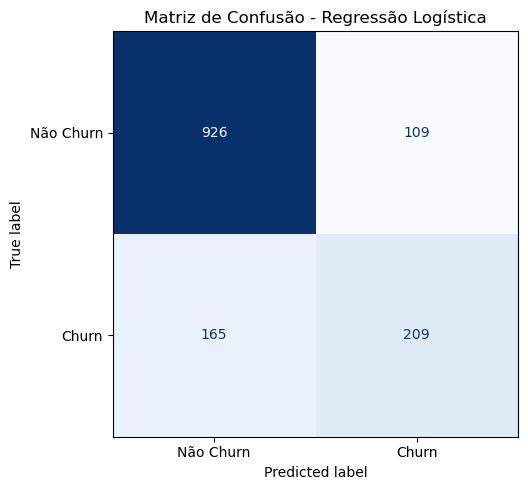

In [ ]:
# ============================================================
# ETAPA 8.2 - VISUALIZAÇÃO DA MATRIZ DE CONFUSÃO
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Não Churn",
        "Churn"
    ]
).plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

ax.set_title("Matriz de Confusão - Regressão Logística")

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# ETAPA 8.3 - INTERPRETAÇÃO DA MATRIZ DE CONFUSÃO
# ============================================================
# Consolidação e interpretação dos resultados da matriz
# de confusão sob a perspectiva técnica e de negócio.
# ============================================================

# Extração dos elementos da matriz de confusão
tn, fp, fn, tp = cm.ravel()


def interpretar_resultado(resultado):
    """
    Gera uma interpretação para cada elemento da matriz de confusão.
    """

    if resultado == "Verdadeiro Negativo (TN)":
        return (
            "Clientes corretamente classificados como não churn, "
            "indicando que permanecerão na empresa."
        )

    elif resultado == "Falso Positivo (FP)":
        return (
            "Clientes classificados como churn, porém que permaneceriam "
            "na empresa."
        )

    elif resultado == "Falso Negativo (FN)":
        return (
            "Clientes que realmente realizaram churn, mas que não foram "
            "identificados pelo modelo."
        )

    elif resultado == "Verdadeiro Positivo (TP)":
        return (
            "Clientes corretamente identificados como churn pelo modelo."
        )

    return ""


def impacto_negocio(resultado):
    """
    Descreve o impacto de cada classificação para o negócio.
    """

    if resultado == "Verdadeiro Negativo (TN)":
        return (
            "Evita ações desnecessárias de retenção, reduzindo custos e "
            "direcionando recursos para clientes com maior risco."
        )

    elif resultado == "Falso Positivo (FP)":
        return (
            "Pode gerar investimentos desnecessários em campanhas de "
            "retenção para clientes que permaneceriam naturalmente."
        )

    elif resultado == "Falso Negativo (FN)":
        return (
            "Representa o cenário mais crítico, pois clientes em risco "
            "não recebem ações preventivas e podem ser perdidos."
        )

    elif resultado == "Verdadeiro Positivo (TP)":
        return (
            "Permite direcionar ações de retenção para clientes com alta "
            "probabilidade de evasão, aumentando a efetividade das campanhas."
        )

    return ""


# Construção da tabela
confusion_df = pd.DataFrame({
    "Resultado": [
        "Verdadeiro Negativo (TN)",
        "Falso Positivo (FP)",
        "Falso Negativo (FN)",
        "Verdadeiro Positivo (TP)"
    ],
    "Quantidade": [
        tn,
        fp,
        fn,
        tp
    ]
})

# Formatação da quantidade
confusion_df["Quantidade"] = (
    confusion_df["Quantidade"]
    .map(lambda x: f"{x:,}".replace(",", "."))
)

# Interpretação técnica
confusion_df["Interpretação"] = (
    confusion_df["Resultado"]
    .apply(interpretar_resultado)
)

# Impacto para o negócio
confusion_df["Impacto para o Negócio"] = (
    confusion_df["Resultado"]
    .apply(impacto_negocio)
)

# Configuração para exibir todo o conteúdo das células
pd.set_option("display.max_colwidth", None)

# Exibição formatada da tabela
display(
    confusion_df.style
        .set_properties(
            subset=["Resultado"],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Quantidade"],
            **{
                "text-align": "center"
            }
        )
        .set_properties(
            subset=["Interpretação"],
            **{
                "text-align": "left",
                "white-space": "normal",
                "min-width": "420px",
            }
        )
        .set_properties(
            subset=["Impacto para o Negócio"],
            **{
                "text-align": "left",
                "white-space": "normal",
                "min-width": "520px",
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold"),
                    ("font-size", "13px"),
                ]
            }
        ])
)

,Resultado,Quantidade,Interpretação,Impacto para o Negócio
0,Verdadeiro Negativo (TN),926,"Clientes corretamente classificados como não churn, indicando que permanecerão na empresa.","Evita ações desnecessárias de retenção, reduzindo custos e direcionando recursos para clientes com maior risco."
1,Falso Positivo (FP),109,"Clientes classificados como churn, porém que permaneceriam na empresa.",Pode gerar investimentos desnecessários em campanhas de retenção para clientes que permaneceriam naturalmente.
2,Falso Negativo (FN),165,"Clientes que realmente realizaram churn, mas que não foram identificados pelo modelo.","Representa o cenário mais crítico, pois clientes em risco não recebem ações preventivas e podem ser perdidos."
3,Verdadeiro Positivo (TP),209,Clientes corretamente identificados como churn pelo modelo.,"Permite direcionar ações de retenção para clientes com alta probabilidade de evasão, aumentando a efetividade das campanhas."


#### Conclusão da ETAPA 8


A matriz de confusão possibilitou uma análise detalhada dos acertos e erros da Regressão Logística, permitindo identificar como o modelo se comportou na classificação dos clientes com e sem churn.

Além da visualização gráfica, a interpretação técnica e a análise do impacto para o negócio demonstraram que diferentes tipos de erro possuem consequências distintas para a empresa. Em especial, os Falsos Negativos representam o cenário de maior criticidade, pois correspondem a clientes que realmente realizaram churn e que não foram identificados pelo modelo a tempo de receber ações de retenção.

Essa análise complementa as métricas apresentadas anteriormente, fornecendo uma compreensão mais aprofundada do desempenho do modelo e dos impactos práticos de suas previsões.

---

### ETAPA 9 - Curva ROC

A Curva ROC (Receiver Operating Characteristic) é uma das principais ferramentas para avaliar modelos de classificação binária.

Diferentemente das métricas calculadas anteriormente, a Curva ROC analisa o comportamento do modelo considerando diferentes limiares de decisão, permitindo avaliar sua capacidade de distinguir corretamente clientes com e sem churn.

Além da curva, será analisada a métrica ROC-AUC (Area Under the Curve), que resume o desempenho geral do classificador em um único valor.

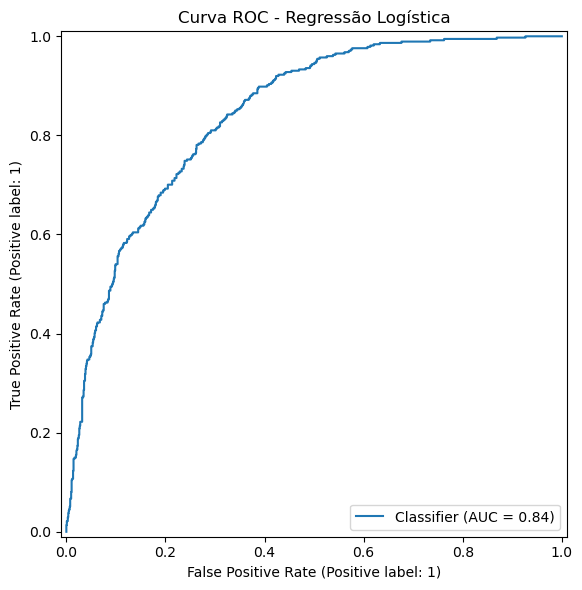

In [ ]:
# ============================================================
# ETAPA 9.1 - CURVA ROC
# ============================================================
# Construção da Curva ROC.
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    ax=ax
)

ax.set_title("Curva ROC - Regressão Logística")

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# ETAPA 9.2 - INTERPRETAÇÃO DA CURVA ROC
# ============================================================
# Interpretação da métrica ROC-AUC.
# ============================================================


def classificar_roc_auc(valor):
    """
    Classifica qualitativamente o desempenho da ROC-AUC.
    """

    if valor >= 0.90:
        return "Excelente"

    elif valor >= 0.80:
        return "Muito boa"

    elif valor >= 0.70:
        return "Boa"

    elif valor >= 0.60:
        return "Moderada"

    else:
        return "Baixa"


def interpretar_roc_auc(valor):
    """
    Gera uma interpretação da ROC-AUC.
    """

    return (
        f"A Regressão Logística apresentou ROC-AUC de {valor:.2%}, "
        "demonstrando sua capacidade de distinguir clientes com churn "
        "e clientes sem churn considerando todos os limiares possíveis "
        "de classificação."
    )


roc_df = pd.DataFrame({
    "Métrica": ["ROC-AUC"],
    "Valor": [round(roc_auc, 4)],
    "Avaliação": [classificar_roc_auc(roc_auc)],
    "Interpretação": [interpretar_roc_auc(roc_auc)]
})

pd.set_option("display.max_colwidth", None)

display(
    roc_df.style
        .set_properties(
            subset=["Métrica", "Valor", "Avaliação"],
            **{"text-align": "center"}
        )
        .set_properties(
            subset=["Interpretação"],
            **{
                "text-align": "left",
                "white-space": "normal",
                "min-width": "600px",
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

,Métrica,Valor,Avaliação,Interpretação
0,ROC-AUC,0.841900,Muito boa,"A Regressão Logística apresentou ROC-AUC de 84.19%, demonstrando sua capacidade de distinguir clientes com churn e clientes sem churn considerando todos os limiares possíveis de classificação."


#### Conclusão da ETAPA 9

A Curva ROC permitiu avaliar a capacidade discriminativa da Regressão Logística considerando diferentes limiares de decisão. O valor de ROC-AUC indicou que o modelo apresenta boa capacidade para distinguir clientes com e sem churn, demonstrando desempenho consistente mesmo quando o limiar de classificação é alterado.

Essa análise complementa as métricas apresentadas anteriormente, fornecendo uma visão mais abrangente da qualidade do modelo e reforçando sua utilização como baseline para comparação com algoritmos mais avançados nas próximas etapas do projeto.

---

### ETAPA 10 - Curva Precision-Recall

A Curva Precision-Recall é uma ferramenta importante para avaliar modelos de classificação em problemas com classes desbalanceadas, como a previsão de churn.

Enquanto a Curva ROC considera simultaneamente a Taxa de Verdadeiros Positivos e a Taxa de Falsos Positivos, a Curva Precision-Recall concentra-se na relação entre Precisão e Recall, fornecendo uma visão mais detalhada da capacidade do modelo em identificar corretamente os clientes com maior risco de evasão.

Nesta etapa será construída a Curva Precision-Recall e analisada a métrica Average Precision (AP), que resume o desempenho da curva em um único valor.

---

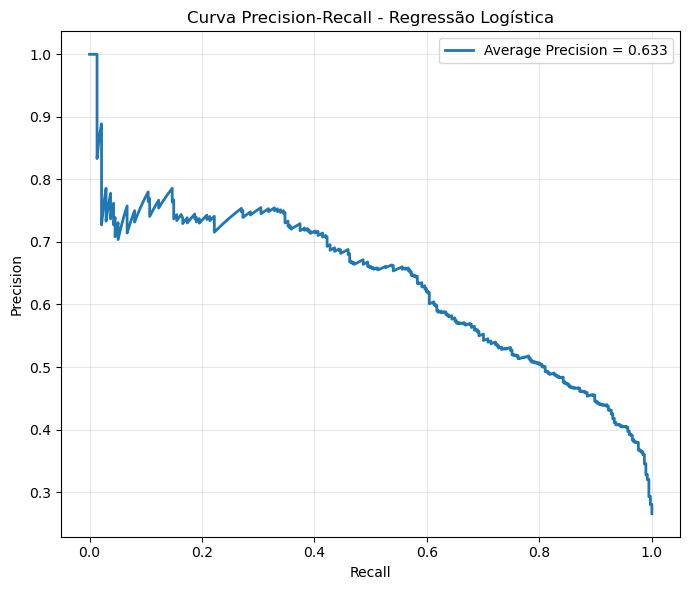

In [ ]:
# ============================================================
# ETAPA 10.1 - CURVA PRECISION-RECALL
# ============================================================

# Calcula a Average Precision
average_precision = average_precision_score(
    y_test,
    y_proba
)

# Calcula os pontos da curva
precision, recall, _ = precision_recall_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Average Precision = {average_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Regressão Logística")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# ETAPA 10.2 - INTERPRETAÇÃO DA CURVA PRECISION-RECALL
# ============================================================
# Interpretação da métrica Average Precision.
# ============================================================

def classificar_average_precision(valor):
    """
    Classifica qualitativamente a Average Precision.
    """

    if valor >= 0.90:
        return "Excelente"

    elif valor >= 0.80:
        return "Muito boa"

    elif valor >= 0.70:
        return "Boa"

    elif valor >= 0.60:
        return "Moderada"

    else:
        return "Baixa"


def interpretar_average_precision(valor):
    """
    Gera uma interpretação da Average Precision.
    """

    return (
        f"A Average Precision foi de {valor:.2%}, indicando o desempenho "
        "global da Curva Precision-Recall e evidenciando a capacidade do "
        "modelo em identificar corretamente clientes com churn, mesmo em "
        "um cenário de classes desbalanceadas."
    )


pr_df = pd.DataFrame({
    "Métrica": ["Average Precision"],
    "Valor": [round(average_precision, 4)],
    "Avaliação": [classificar_average_precision(average_precision)],
    "Interpretação": [interpretar_average_precision(average_precision)]
})

display(
    pr_df.style
        .set_properties(
            subset=["Métrica", "Valor", "Avaliação"],
            **{"text-align": "center"}
        )
        .set_properties(
            subset=["Interpretação"],
            **{
                "text-align": "left",
                "white-space": "normal",
                "min-width": "600px"
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

,Métrica,Valor,Avaliação,Interpretação
0,Average Precision,0.633400,Moderada,"A Average Precision foi de 63.34%, indicando o desempenho global da Curva Precision-Recall e evidenciando a capacidade do modelo em identificar corretamente clientes com churn, mesmo em um cenário de classes desbalanceadas."


#### Conclusão da ETAPA 10

A Curva Precision-Recall complementou a análise da Curva ROC ao avaliar o equilíbrio entre Precisão e Recall para diferentes limiares de classificação. A métrica Average Precision resumiu esse comportamento em um único indicador, evidenciando o desempenho do modelo na identificação de clientes com churn em um contexto de classes desbalanceadas.

Essa análise é especialmente relevante para problemas de retenção de clientes, pois permite avaliar a eficiência do modelo em identificar corretamente clientes com maior probabilidade de evasão, reduzindo tanto perdas de oportunidades quanto ações de retenção desnecessárias.

---

### ETAPA 11 - Conclusão Geral

Ao longo deste notebook foi desenvolvido um modelo baseline utilizando Regressão Logística para previsão de churn de clientes da empresa Telco.

Desde a preparação dos dados até a avaliação do desempenho do modelo, foram aplicadas boas práticas de Ciência de Dados, incluindo pré-processamento automatizado, construção de Pipeline, treinamento, geração de previsões e análise por meio de diferentes métricas e visualizações.

Nesta etapa são apresentados os principais resultados obtidos e as considerações finais sobre o desempenho do modelo.

In [ ]:
# ============================================================
# ETAPA 11.1 - RESUMO EXECUTIVO
# ============================================================

conclusao_df = pd.DataFrame({
    "Aspecto Avaliado": [
        "Preparação dos Dados",
        "Pré-processamento",
        "Modelo",
        "Avaliação",
        "Objetivo do Baseline"
    ],
    "Resultado": [
        "Dados tratados e preparados para modelagem.",
        "Pipeline automatizado com imputação, padronização e One-Hot Encoding.",
        "Regressão Logística treinada com sucesso.",
        "Desempenho avaliado por métricas, matriz de confusão, Curva ROC e Curva Precision-Recall.",
        "Servirá como referência para comparação com modelos mais avançados."
    ]
})

display(
    conclusao_df.style
        .set_properties(
            subset=["Aspecto Avaliado"],
            **{"text-align": "center"}
        )
        .set_properties(
            subset=["Resultado"],
            **{
                "text-align": "left",
                "white-space": "normal",
                "min-width": "650px"
            }
        )
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

,Aspecto Avaliado,Resultado
0,Preparação dos Dados,Dados tratados e preparados para modelagem.
1,Pré-processamento,"Pipeline automatizado com imputação, padronização e One-Hot Encoding."
2,Modelo,Regressão Logística treinada com sucesso.
3,Avaliação,"Desempenho avaliado por métricas, matriz de confusão, Curva ROC e Curva Precision-Recall."
4,Objetivo do Baseline,Servirá como referência para comparação com modelos mais avançados.


#### Conclusão da ETAPA 11

O modelo baseline desenvolvido com Regressão Logística apresentou desempenho consistente na previsão de churn, demonstrando boa capacidade de identificar padrões relacionados à evasão de clientes.

A utilização de um Pipeline automatizado tornou o processo de preparação dos dados mais robusto e reprodutível, enquanto as métricas de avaliação, a matriz de confusão e as curvas ROC e Precision-Recall forneceram uma visão abrangente sobre os pontos fortes e as limitações do modelo.

Embora a Regressão Logística seja um algoritmo relativamente simples, seus resultados estabelecem uma referência sólida para comparação com modelos mais sofisticados, como Random Forest, XGBoost e LightGBM, que serão explorados nas próximas etapas do projeto.

Dessa forma, este notebook cumpre seu papel como baseline do problema de previsão de churn, servindo como ponto de partida para a evolução das análises e para a busca por modelos com maior capacidade preditiva.

---